In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.image as mpimg

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue', 'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

In [5]:
amino_acids = ['A', 'R', 'N', 'D', 'C',
               'E', 'Q', 'G', 'H', 'I',
               'L', 'K', 'M', 'F', 'P',
               'S', 'T', 'W', 'Y', 'V']

amino_frac = [0.0, 10.5, 5.3, 7.9, 0.0,
              7.9, 0.0, 7.9, 18.4, 0.0,
              2.6, 7.9, 0.0, 7.9, 2.6,
              7.9, 0.0, 0.0, 13.2, 0.0]

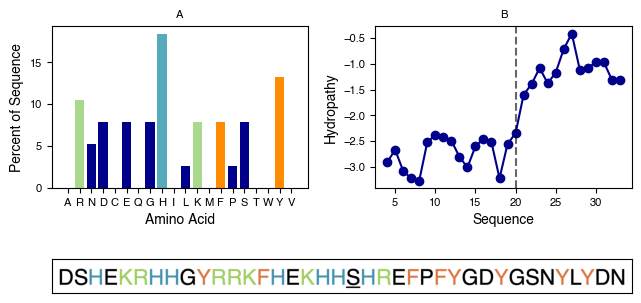

In [7]:
fig = plt.figure(figsize=((16*cm), (8*cm)), layout='constrained')
ax = fig.subplot_mosaic(
    [
        ['p1', 'p2'],
        ['p1', 'p2'],
        ['p3', 'p3'],
    ],
)

work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/'
seq, hydro = np.genfromtxt((work_dir + 'Hst1_hydro.txt'), usecols=(0, 1), unpack=True)
for (aa, af) in zip(amino_acids, amino_frac):
    if aa in ['Y', 'F', 'W']:
        ax['p1'].bar(aa, af, color=color_list[99])
    elif aa in ['R', 'K']:
        ax['p1'].bar(aa, af, color=color_list[66])
    elif aa == 'H':
        ax['p1'].bar(aa, af, color=color_list[33])
    else:
        ax['p1'].bar(aa, af, color=color_list[0])
ax['p2'].plot(seq, hydro, color=color_list[0], marker='o')
ax['p2'].axvline(20, linestyle='--', color='black', alpha=0.6)
img = mpimg.imread('/Users/oskarsvensson/Desktop/Current/Hst1_asso/seq.png')
ax['p3'].imshow(img)

ax['p1'].tick_params(labelsize=font)
ax['p2'].tick_params(labelsize=font)
ax['p3'].set_xticks([])
ax['p3'].set_yticks([])
ax['p1'].set_xlabel('Amino Acid', fontsize=font_label)
ax['p2'].set_xlabel('Sequence', fontsize=font_label)
ax['p1'].set_ylabel('Percent of Sequence', fontsize=font_label)
ax['p2'].set_ylabel('Hydropathy', fontsize=font_label)
ax['p1'].set_title('A', fontsize=font)
ax['p2'].set_title('B', fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/Sequence_analysis.pdf', dpi=1000)